In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cmap = plt.get_cmap("hot")

colors = [cmap(x) for x in np.linspace(0.1, 0.9, 5)]

In [3]:
data_name = "dayu_d18o"
version = 2

## dayu_edited
# HMC_energy = np.load(f"HMC/output/{data_name}/{version}/907f84572d/energy.npy")
# PT_energy_partial = np.load(f"PT_partial_likelihood/output/{data_name}/{version}/800f5fc362/energy.npy")
# PT_energy_full = np.load(f"PT_full_likelihood/output/{data_name}/{version}/800f5fc362/energy.npy")

# OPES_energy_partial = np.load(f"OPES_partial_likelihood/output/{data_name}/{version}/a5386a877f/energy.npy")
# OPES_energy_full = np.load(f"OPES_full_likelihood/output/{data_name}/{version}/a5386a877f/energy.npy")
# OPES_bias_partial = np.load(f"OPES_partial_likelihood/output/{data_name}/{version}/a5386a877f/bias.npy")
# OPES_bias_full = np.load(f"OPES_full_likelihood/output/{data_name}/{version}/a5386a877f/bias.npy") 

## Wah
# HMC_energy = np.load(f"HMC/output/{data_name}/{version}/96ca9b4ef2/energy.npy")
# PT_energy_partial = np.load(f"PT_partial_likelihood/output/{data_name}/{version}/4c94c93eb1/energy.npy")
# PT_energy_full = np.load(f"PT_full_likelihood/output/{data_name}/{version}/4c94c93eb1/energy.npy")

# OPES_energy_partial = np.load(f"OPES_partial_likelihood/output/{data_name}/{version}/b1a04a02b3/energy.npy")
# OPES_energy_full = np.load(f"OPES_full_likelihood/output/{data_name}/{version}/b1a04a02b3/energy.npy")
# OPES_bias_partial = np.load(f"OPES_partial_likelihood/output/{data_name}/{version}/b1a04a02b3/bias.npy")
# OPES_bias_full = np.load(f"OPES_full_likelihood/output/{data_name}/{version}/b1a04a02b3/bias.npy")

## Dayu
HMC_energy = np.load(f"HMC/output/{data_name}/{version}/0b0c828856/energy.npy")
PT_energy_partial = np.load(f"PT_partial_likelihood/output/{data_name}/{version}/9e0652caf8/energy.npy")
PT_energy_full = np.load(f"PT_full_likelihood/output/{data_name}/{version}/9e0652caf8/energy.npy")

OPES_energy_partial = np.load(f"OPES_partial_likelihood/output/{data_name}/{version}/1e337b1a88/energy.npy")
OPES_energy_full = np.load(f"OPES_full_likelihood/output/{data_name}/{version}/1e337b1a88/energy.npy")
OPES_bias_partial = np.load(f"OPES_partial_likelihood/output/{data_name}/{version}/1e337b1a88/bias.npy")
OPES_bias_full = np.load(f"OPES_full_likelihood/output/{data_name}/{version}/1e337b1a88/bias.npy")


In [4]:
def running_weighted_mean(obs, weights, W):
    """
    obs:      shape (nchains, nsamples)
    weights:  shape (nchains, nsamples)
    W:        window size

    returns:
        running_mean: shape (nsamples,)
    """

    nchains, nsamples = obs.shape

    numerator = obs * weights

    # Sum over chains first
    numerator = numerator.sum(axis=0)
    denominator = weights.sum(axis=0)

    # Running cumulative sums
    cnum = np.cumsum(numerator)
    cden = np.cumsum(denominator)

    running = np.empty(nsamples)

    for t in range(nsamples):
        left = max(0, t - W + 1)

        if left == 0:
            num = cnum[t]
            den = cden[t]
        else:
            num = cnum[t] - cnum[left - 1]
            den = cden[t] - cden[left - 1]

        running[t] = num / den

    return running

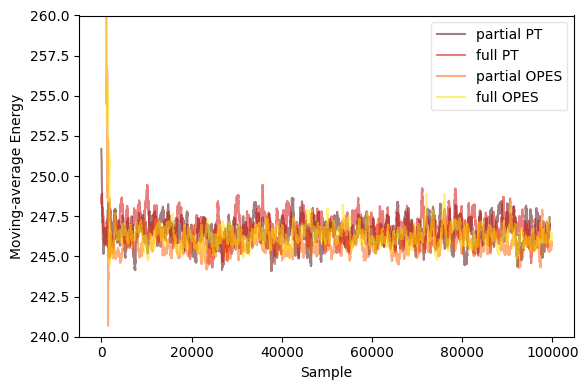

In [8]:
window = 500

fig, ax = plt.subplots(figsize=(6, 4))

hmc_ma = np.convolve(HMC_energy[0, 100:], np.ones(window)/window, mode='valid')
ptp_ma = np.convolve(PT_energy_partial[-1, 100:], np.ones(window)/window, mode='valid')
ptf_ma = np.convolve(PT_energy_full[-1, 100:], np.ones(window)/window, mode='valid')

opesp_ma = running_weighted_mean(OPES_energy_partial[:, 100:], np.exp(OPES_bias_partial[:, 100:]), window)
opesf_ma = running_weighted_mean(OPES_energy_full[:, 100:], np.exp(OPES_bias_full[:, 100:]), window)

ax.plot(ptp_ma, label="partial PT", alpha = 0.5, color = colors[0])
ax.plot(ptf_ma, label="full PT", alpha = 0.5, color = colors[1])
ax.plot(opesp_ma, label="partial OPES", alpha = 0.5, color = colors[2])
ax.plot(opesf_ma, label="full OPES", alpha = 0.5, color = colors[3])
# ax.plot(hmc_ma, label="HMC", alpha = 0.5, color = colors[4])

ax.legend(framealpha=0.5, loc = "upper right")
ax.set_xlabel("Sample")
ax.set_ylabel("Moving-average Energy")
# plt.ylim([230, 260])
# plt.ylim([350, 600])
plt.ylim([240, 260])
plt.tight_layout()
plt.savefig(f"comparison_{data_name}.jpg")
plt.show()